# Sewer overflow predictions

In [30]:
import copy
import numpy as np
import pandas as pd
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, f_regression
from sklearn.metrics import mean_absolute_error, mean_squared_error, precision_score, recall_score, f1_score
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.neural_network import MLPRegressor

# setting pandas option to avoid silent downcasting of data types
pd.set_option('future.no_silent_downcasting', True)

In [31]:
# COLAB SETUP — safe to skip if running locally (generated by Claude). Allows different members of the project to run the code either in google colab or locally.
# This code snippet copies our project's github repo to the google colab environment.
import os, sys
if 'google.colab' in sys.modules:
    if not os.path.exists('/content/overflow-prediction'):
        !git clone https://github.com/miirage-exe/overflow-prediction.git
    os.chdir('/content/overflow-prediction') # Change the current working directory so relative paths like "./data" etc... in the code below works.

## Data fetching and merging

In [32]:
# Fetch pluviometer and sewage data of a specific year from the files
def fetch_datasets(year):
  df_pluv = pd.read_excel(f'data/pluviometer/{year}.xlsx')
  df_sew = pd.read_csv(f'data/sewage/U24_{year}.csv')

  # cleaning of pluviometer dataset

  # renaming columns
  labels = df_pluv.columns[1:3] # Get second and third columns name (differs between 2022 and 2023)
  df_pluv = df_pluv.rename(columns={"FLOWBRU - PLUVIO ALL":"datetime", labels[0]:"precip_avant_port", labels[1]:"precip_flagey" })

  # keep only usefull columns and rows
  df_pluv = df_pluv[["datetime", "precip_avant_port", "precip_flagey"]]
  df_pluv = df_pluv[1:-13] # Remove first row (labels in the excel file) and last one (totals per month)

  # Ensure precipitation columns are numeric (Excel may read them as object/string dtype)
  df_pluv['precip_avant_port'] = pd.to_numeric(df_pluv['precip_avant_port'], errors='coerce')
  df_pluv['precip_flagey'] = pd.to_numeric(df_pluv['precip_flagey'], errors='coerce')

  # converting to datetime
  df_pluv['datetime'] = pd.to_datetime(df_pluv["datetime"], format='%d-%m-%Y %H:%M')

  # sort the dataframe by datetime, to ensure chronological order
  df_pluv = df_pluv.sort_values(by="datetime").reset_index(drop=True) # We use .reset_index(drop=True), otherwise the old index will be added as a new column, which we do not want
  df_pluv = df_pluv.set_index("datetime") # Set datetime as index of the dataframe, meaning we will use it to reference the rows

  # cleaning of sewage dataset

  # renaming columns
  df_sew = df_sew.rename(columns={"Date":"datetime", "Value":"water_level" })

  # converting to datetime
  df_sew['datetime'] = pd.to_datetime(df_sew["datetime"])

  # sort the dataframe by datetime, to ensure chronological order
  df_sew = df_sew.sort_values(by="datetime").reset_index(drop=True) # We use .reset_index(drop=True), otherwise the old index will be added as a new column, which we do not want
  df_sew = df_sew.set_index("datetime") # Set datetime as index of the dataframe, meaning we will use it to reference the rows

  return df_pluv, df_sew

In [33]:
def clean_and_merge_datasets(year, sample_rate='5min'):

    df_pluv, df_sew = fetch_datasets(year)

    # Data cleaning
    # After plotting raw data, we detected some outlier values (-1000 in water level) so we filter them.
    df_sew = df_sew[df_sew['water_level'] >= 0]

    # Resampling to a strict 5-minute grid
    # Rainfall: taking the max() or sum() is safer than first() in case there are slight timestamp duplicates
    df_pluv = df_pluv.resample(sample_rate).max() 
    
    # Sewage: resample from 1-min to 5-min, keeping the maximum level (worst case)
    df_sew = df_sew.resample(sample_rate).max() 

    # Merging: Use 'outer' so we don't lose time steps if one sensor temporarily fails
    df_merged = df_pluv.merge(df_sew, on="datetime", how='outer')
    
    # Sort the index just in case the merge scrambled the chronological order
    df_merged = df_merged.sort_index()

    # Handle Missing Values (NaNs)
    # For water level, forward-fill (carry the last known value forward) is a standard approach for short gaps
    df_merged['water_level'] = df_merged['water_level'].ffill() 
    
    # For rainfall, we think missing data often means the sensor recorded nothing (0 mm). 
    # note: If the rain gauge records cumulative rain, we should use .ffill() instead. 
    df_merged = df_merged.fillna(0).infer_objects(copy=False)

    return df_merged

In [34]:
# For each year, merge pluviometer and sewage data
time_sample = '5min'

df_2022 = clean_and_merge_datasets(2022, time_sample)
df_2023 = clean_and_merge_datasets(2023, time_sample)
df_2024 = clean_and_merge_datasets(2024, time_sample)

# Our final dataset, concatenation of each year.
df = pd.concat([df_2022, df_2023, df_2024])

## (Plot) Visualize data

<Axes: xlabel='datetime'>

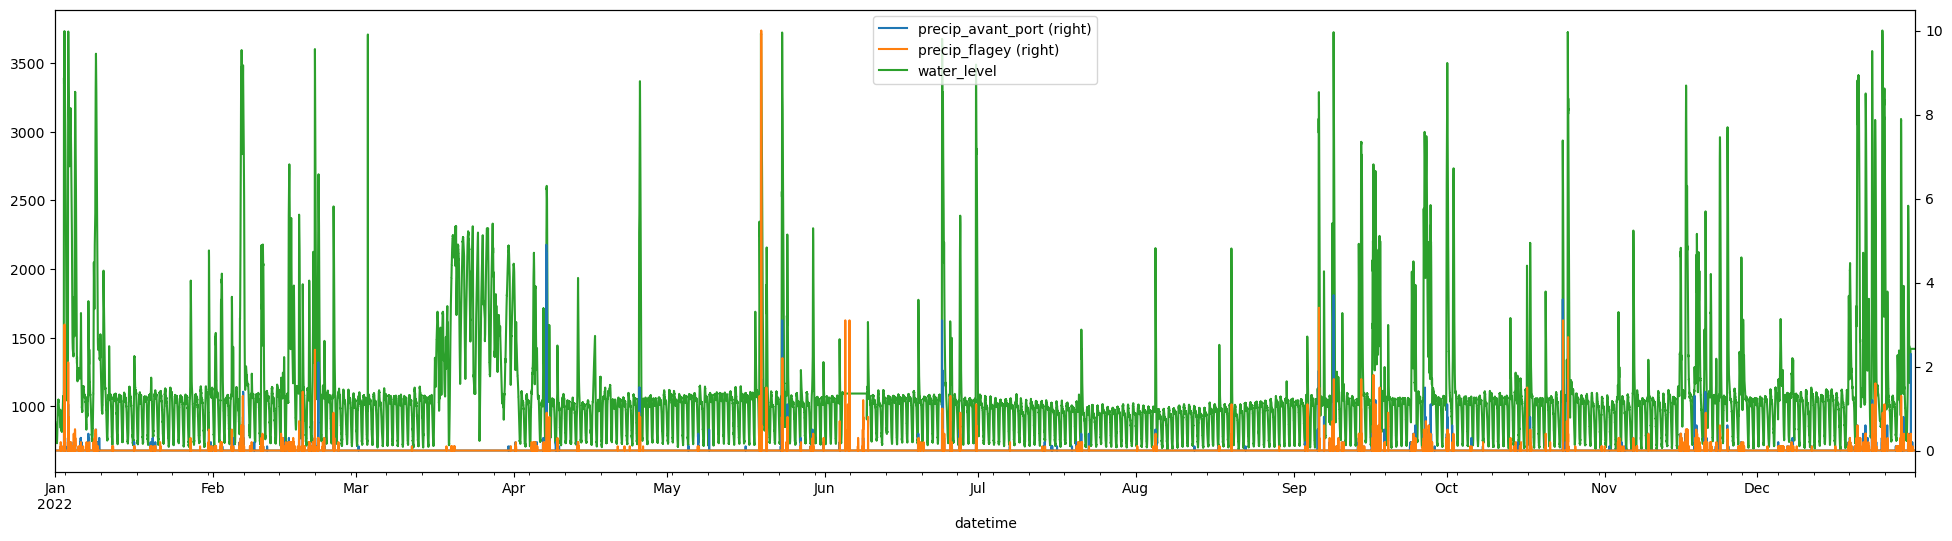

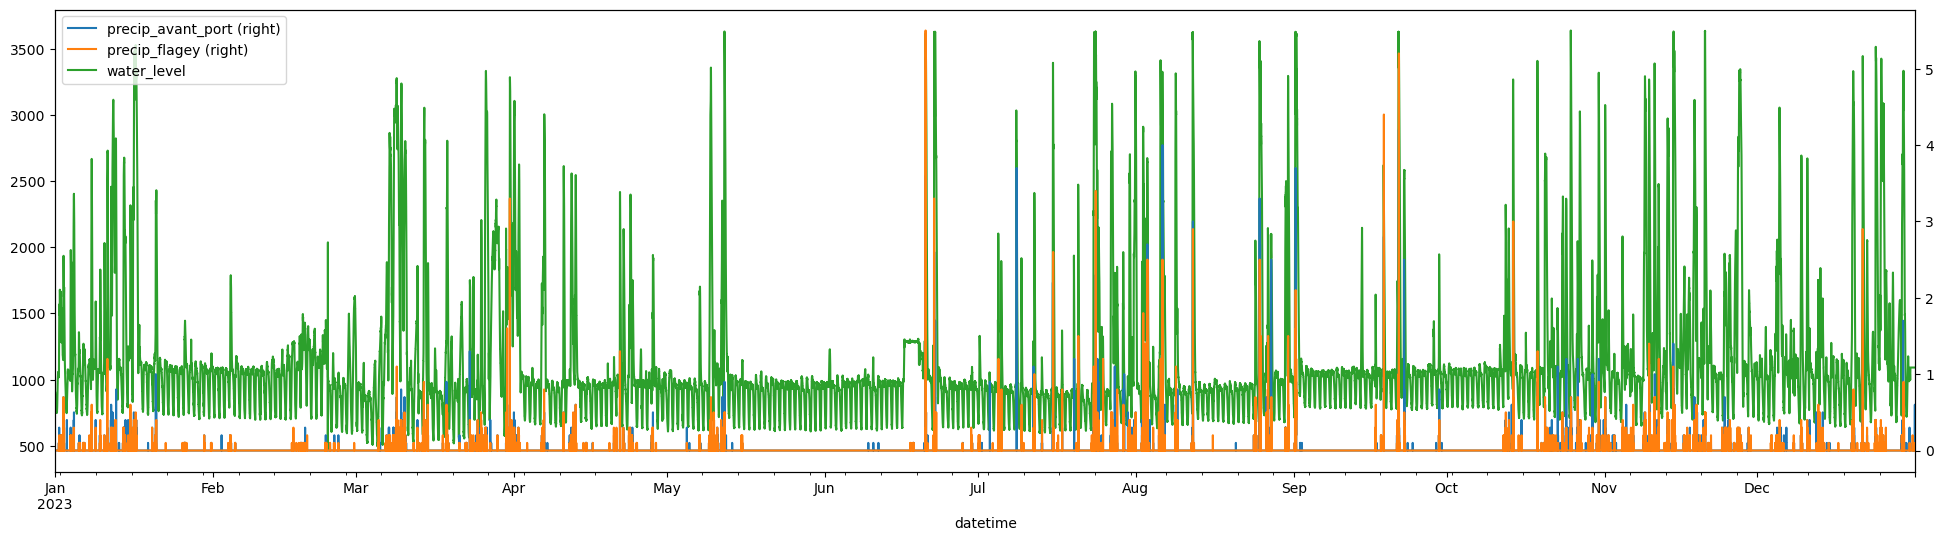

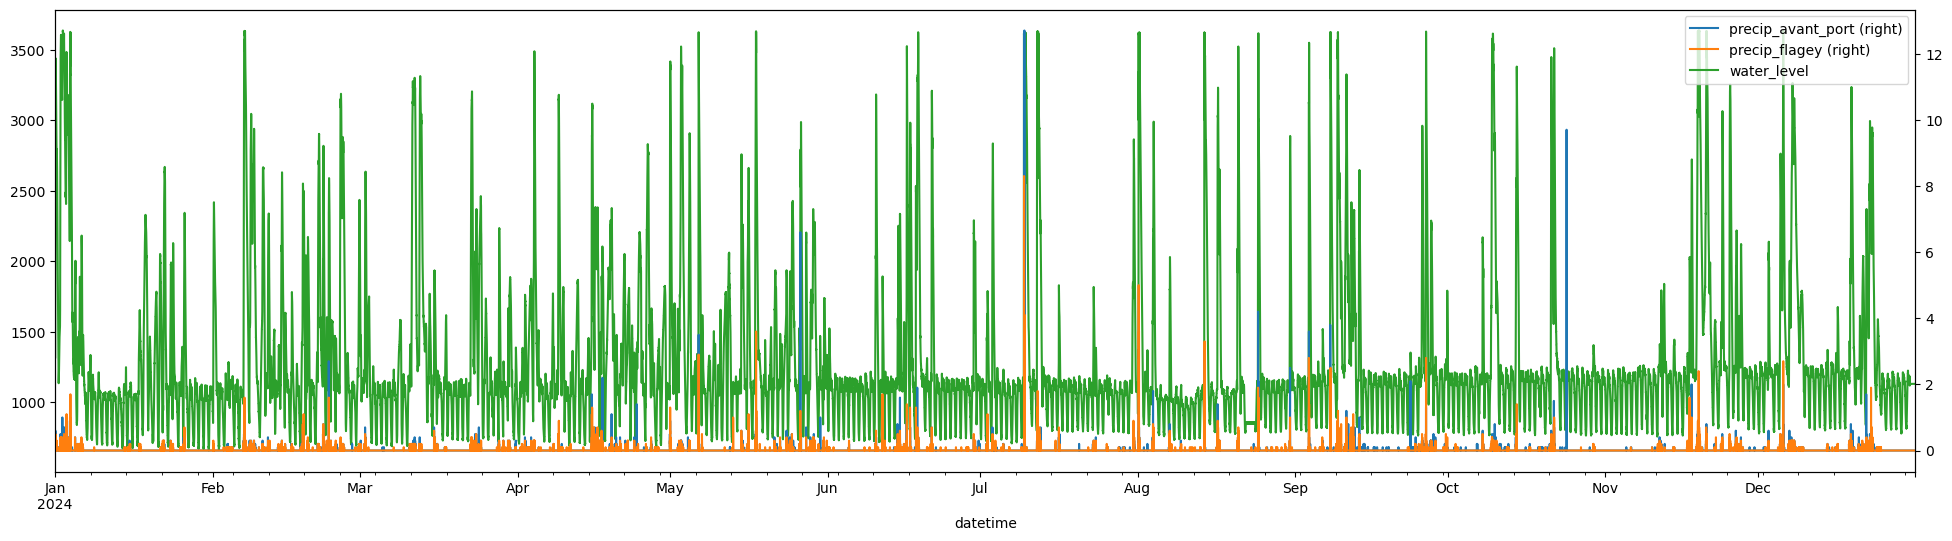

In [35]:
df_2022.plot(figsize=(24,6), secondary_y=['precip_avant_port', 'precip_flagey'])
df_2023.plot(figsize=(24,6), secondary_y=['precip_avant_port', 'precip_flagey'])
df_2024.plot(figsize=(24,6), secondary_y=['precip_avant_port', 'precip_flagey'])

## Feature Engineering

To predict the future, model needs to know:

1- Baseflow / Time patterns: People use more water in the mornings/evenings than at 3 AM.

2- Recent History (Lags): Is the water level currently rising or falling? It needs to see the past few time-steps.

3- The Target (Future): we need to create the columns that the model is actually trying to predict ($t+15$ and $t+60$)

In [36]:
# Baseflow (Temporal) Features
df['hour'] = df.index.hour
df['day_of_week'] = df.index.dayofweek
df['is_weekend'] = df.index.dayofweek.isin([5, 6]).astype(int)

# Lag Features (Past Data)
# Shift by 1 means looking 5 minutes into the past.
lags = [1, 2, 3, 6, 9, 12] # 5, 10, 15, 30, 45, and 60 mins ago
for lag in lags:
    df[f'water_level_lag_{lag}'] = df['water_level'].shift(lag)
    df[f'precip_avant_port_lag_{lag}'] = df['precip_avant_port'].shift(lag)
    df[f'precip_flagey_lag_{lag}'] = df['precip_flagey'].shift(lag)

# Target Variables (Future Data)
# t+15 mins = 3 rows ahead (negative shift)
df['target_water_level_15m'] = df['water_level'].shift(-3)
# t+60 mins = 12 rows ahead
df['target_water_level_60m'] = df['water_level'].shift(-12)

# Clean up NaNs created by shifting at the boundaries
df = df.dropna()

print(f"Dataset shape after feature engineering: {df.shape}")

Dataset shape after feature engineering: (315598, 26)


## Setup, Metrics, and Chronological Split
In WPO 3, we learned to split data into Train, Validation, and Test sets. For time series, we must do this chronologically without shuffling

In [ ]:
random_state = 42

# Define the NSE metric function (Hydrology metric requested in PDF)
def nse(y_true, y_pred):
    return 1 - (np.sum((y_true - y_pred)**2) / np.sum((y_true - np.mean(y_true))**2))

# Define Features (X) and Targets (y)
features = [col for col in df.columns if 'target' not in col]
X = df[features]
y_15 = df['target_water_level_15m']
y_60 = df['target_water_level_60m']

# Chronological Split (70% Train, 15% Validation, 15% Test)
# We did not use train_test_split with shuffle=True for time series
train_size = int(len(df) * 0.7)
val_size = int(len(df) * 0.15)

X_train = X.iloc[:train_size]
X_val = X.iloc[train_size:train_size + val_size]
X_test = X.iloc[train_size + val_size:]

# Separate targets for 15-min and 60-min horizons
y_train_15 = y_15.iloc[:train_size]
y_val_15 = y_15.iloc[train_size:train_size + val_size]
y_test_15 = y_15.iloc[train_size + val_size:]

y_train_60 = y_60.iloc[:train_size]
y_val_60 = y_60.iloc[train_size:train_size + val_size]
y_test_60 = y_60.iloc[train_size + val_size:]

## Build Scikit-Learn Pipelines
Following the WPO 3 structure, we will put the StandardScaler, SelectKBest (feature selection), and the model into a Pipeline

In [38]:
# Define the 3 models
# Note: MLP is the Simple Neural Network seen in WPO 4
models = {
    "Ridge Regression": Ridge(alpha=1.0, random_state=random_state),
    "Random Forest": RandomForestRegressor(n_estimators=50, max_depth=10, random_state=random_state, n_jobs=-1), 
    "Neural Network": MLPRegressor(hidden_layer_sizes=(32, 16), max_iter=300, random_state=random_state, early_stopping=True)
}

# Create a dictionary of pipelines
pipelines = {}
for name, model in models.items():
    pipelines[name] = Pipeline([
        ('scaler', StandardScaler()), # WPO 4: Always scale for MLPs & Linear models
        ('selector', SelectKBest(score_func=f_regression, k=15)), # WPO 3: Feature selection (k=15 out of ~22 features)
        ('model', model)
    ])

## Model Training and Regression Evaluation
We will evaluate the models using MAE, RMSE, and Bias, alongside the custom NSE metric.

In [39]:
def train_and_evaluate(pipelines, X_train, y_train, X_val, y_val, X_test, y_test, horizon):
    print(f"\n{'='*40}")
    print(f" RESULTS FOR {horizon} MINUTES AHEAD ")
    print(f"{'='*40}")
    
    predictions_dict = {}
    
    for name, pipeline in pipelines.items():
        # Train the pipeline
        pipeline.fit(X_train, y_train)
        
        # Predict on Validation and Test sets
        y_val_pred = pipeline.predict(X_val)
        y_pred = pipeline.predict(X_test)
        predictions_dict[name] = y_pred
        
        # Calculate Regression Metrics on Validation set
        val_mae = mean_absolute_error(y_val, y_val_pred)
        val_rmse = np.sqrt(mean_squared_error(y_val, y_val_pred))
        val_nse = nse(y_val.values, y_val_pred)

        # Calculate Regression Metrics on Test set (From WPO 2)
        mae = mean_absolute_error(y_test, y_pred)
        rmse = np.sqrt(mean_squared_error(y_test, y_pred))
        bias = np.mean(y_pred - y_test) # average error (predicted - true)
        
        # Custom Hydrology Metric
        model_nse = nse(y_test.values, y_pred)
        
        print(f"\n{name}:")
        print(f"  VAL  -> RMSE: {val_rmse:.2f} mm | MAE: {val_mae:.2f} mm | NSE: {val_nse:.3f}")
        print(f"  TEST -> RMSE: {rmse:.2f} mm | MAE: {mae:.2f} mm | Bias: {bias:.2f} mm | NSE: {model_nse:.3f}")
        
    return predictions_dict

# Run training and evaluation for 15 minutes ahead
preds_15 = train_and_evaluate(pipelines, X_train, y_train_15, X_val, y_val_15, X_test, y_test_15, "15")

# Run training and evaluation for 60 minutes ahead
# Use deepcopy so the 15-min trained models are not overwritten by the second fit()
preds_60 = train_and_evaluate(copy.deepcopy(pipelines), X_train, y_train_60, X_val, y_val_60, X_test, y_test_60, "60")


 RESULTS FOR 15 MINUTES AHEAD 

Ridge Regression:
  VAL  -> RMSE: 45.82 mm | MAE: 13.70 mm | NSE: 0.993
  TEST -> RMSE: 38.07 mm | MAE: 11.01 mm | Bias: -1.32 mm | NSE: 0.995

Random Forest:
  VAL  -> RMSE: 39.44 mm | MAE: 14.63 mm | NSE: 0.995
  TEST -> RMSE: 33.53 mm | MAE: 11.89 mm | Bias: -2.43 mm | NSE: 0.996

Neural Network:
  VAL  -> RMSE: 44.38 mm | MAE: 12.99 mm | NSE: 0.994
  TEST -> RMSE: 41.33 mm | MAE: 10.87 mm | Bias: -3.26 mm | NSE: 0.994

 RESULTS FOR 60 MINUTES AHEAD 

Ridge Regression:
  VAL  -> RMSE: 140.82 mm | MAE: 63.56 mm | NSE: 0.935
  TEST -> RMSE: 128.87 mm | MAE: 49.16 mm | Bias: -9.29 mm | NSE: 0.940

Random Forest:
  VAL  -> RMSE: 128.36 mm | MAE: 60.53 mm | NSE: 0.946
  TEST -> RMSE: 120.00 mm | MAE: 48.61 mm | Bias: -7.56 mm | NSE: 0.948

Neural Network:
  VAL  -> RMSE: 132.67 mm | MAE: 57.19 mm | NSE: 0.942
  TEST -> RMSE: 124.81 mm | MAE: 45.15 mm | Bias: -7.90 mm | NSE: 0.944


## Overflow Classification
Now we apply the 3000 mm threshold to our regression predictions to evaluate how well they classify overflows, calculating Precision, Recall, and F1-Score to handle the class imbalance.

In [40]:
OVERFLOW_THRESHOLD = 3000

def evaluate_overflow(y_true_continuous, y_pred_continuous, baseline_continuous, model_name, horizon):
    # Convert continuous water levels to binary Overflow classes (1 = Overflow, 0 = Normal)
    y_true_class = (y_true_continuous > OVERFLOW_THRESHOLD).astype(int)
    y_pred_class = (y_pred_continuous > OVERFLOW_THRESHOLD).astype(int)
    baseline_class = (baseline_continuous > OVERFLOW_THRESHOLD).astype(int)
    
    # Calculate classification metrics for the Model
    precision = precision_score(y_true_class, y_pred_class, zero_division=0)
    recall = recall_score(y_true_class, y_pred_class, zero_division=0)
    f1 = f1_score(y_true_class, y_pred_class, zero_division=0)
    
    # Calculate classification metrics for the Baseline
    b_precision = precision_score(y_true_class, baseline_class, zero_division=0)
    b_recall = recall_score(y_true_class, baseline_class, zero_division=0)
    b_f1 = f1_score(y_true_class, baseline_class, zero_division=0)
    
    print(f"\nOverflow Detection for {model_name} ({horizon}m ahead):")
    print(f"  MODEL    -> Precision: {precision:.3f} | Recall: {recall:.3f} | F1: {f1:.3f}")
    print(f"  BASELINE -> Precision: {b_precision:.3f} | Recall: {b_recall:.3f} | F1: {b_f1:.3f}")

# The Baseline Persistence Model (Assuming steady-state: y_future = y_current)
# "water_level" is our current time 't' value
baseline_predictions_test = X_test['water_level'].values

print("--- 15 Minutes Ahead ---")
for model_name in preds_15:
    evaluate_overflow(y_test_15.values, preds_15[model_name], baseline_predictions_test, model_name, "15")

print("\n--- 60 Minutes Ahead ---")
for model_name in preds_60:
    evaluate_overflow(y_test_60.values, preds_60[model_name], baseline_predictions_test, model_name, "60")

--- 15 Minutes Ahead ---

Overflow Detection for Ridge Regression (15m ahead):
  MODEL    -> Precision: 0.977 | Recall: 0.949 | F1: 0.963
  BASELINE -> Precision: 0.945 | Recall: 0.945 | F1: 0.945

Overflow Detection for Random Forest (15m ahead):
  MODEL    -> Precision: 0.962 | Recall: 0.975 | F1: 0.968
  BASELINE -> Precision: 0.945 | Recall: 0.945 | F1: 0.945

Overflow Detection for Neural Network (15m ahead):
  MODEL    -> Precision: 0.994 | Recall: 0.931 | F1: 0.961
  BASELINE -> Precision: 0.945 | Recall: 0.945 | F1: 0.945

--- 60 Minutes Ahead ---

Overflow Detection for Ridge Regression (60m ahead):
  MODEL    -> Precision: 0.961 | Recall: 0.774 | F1: 0.858
  BASELINE -> Precision: 0.781 | Recall: 0.781 | F1: 0.781

Overflow Detection for Random Forest (60m ahead):
  MODEL    -> Precision: 0.909 | Recall: 0.828 | F1: 0.867
  BASELINE -> Precision: 0.781 | Recall: 0.781 | F1: 0.781

Overflow Detection for Neural Network (60m ahead):
  MODEL    -> Precision: 0.946 | Recall: 0.76